# CS4305 Artificial Intelligence — Lab 5
## Problem Solving as Search

**What you will learn today**
1. Describe a problem using the **5 parts**: initial state, actions, result, goal test, path cost
2. Represent a **road map** as a graph in Python
3. See how a **search tree** grows
4. Solve the **Water Jug** problem and the **8-puzzle** by exploring states

**How to use this notebook**
- 📊 **Visual explanation** cells already show a picture. Look at the picture first, then read the code.
- 💻 **Code** cells: click inside and press **Shift + Enter** to run them, from top to bottom.
- 📝 **Lab tasks** are at the end.

In [ ]:
#@title ⚙️ Diagram tools (only needed if you want to redraw the pictures)
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, Rectangle

PURPLE, ORANGE, TEAL, ROSE, DARK = "#5B2A86", "#FF9F1C", "#1FA898", "#D1495B", "#1A1333"
LIGHT, GREY, WHITE = "#F3EEFA", "#A9A3B8", "#FFFFFF"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 12})

def tree_layout(children, root, gap=1.0):
    """Tidy layout for a tree given as {parent: [children]}."""
    pos, nxt = {}, [0.0]
    def walk(n, d):
        kids = children.get(n, [])
        if not kids:
            pos[n] = (nxt[0], -d); nxt[0] += gap
        else:
            for k in kids: walk(k, d + 1)
            xs = [pos[k][0] for k in kids]
            pos[n] = ((min(xs) + max(xs)) / 2, -d)
    walk(root, 0)
    return pos

def draw_graph(ax, pos, edges, directed=False, weights=None, colors=None, path=None, r=0.28,
               fs=13, label_below=False, badges=None, badge_color=ORANGE, edge_fs=11, names=None):
    """Draw nodes (circles) and edges. path = list of nodes to highlight in orange."""
    colors = colors or {}
    on_path = set()
    if path:
        for a, b in zip(path, path[1:]): on_path |= {(a, b), (b, a)}
    for i, (a, b) in enumerate(edges):
        (x1, y1), (x2, y2) = pos[a], pos[b]
        L = math.hypot(x2 - x1, y2 - y1); ux, uy = (x2 - x1) / L, (y2 - y1) / L
        s, e = (x1 + ux * r, y1 + uy * r), (x2 - ux * r, y2 - uy * r)
        hi = (a, b) in on_path
        ax.annotate("", xy=e, xytext=s, arrowprops=dict(arrowstyle="-|>" if directed else "-",
                    color=ORANGE if hi else GREY, lw=4 if hi else 1.8, shrinkA=0, shrinkB=0,
                    mutation_scale=18), zorder=1)
        if weights:
            w = weights[i]
            ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(w), ha="center", va="center", fontsize=edge_fs,
                    color=DARK, fontweight="bold", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.2", fc=WHITE, ec="none"))
    for n, (x, y) in pos.items():
        c = colors.get(n, PURPLE)
        ax.add_patch(Circle((x, y), r, fc=c, ec=WHITE, lw=2, zorder=3))
        text = (names or {}).get(n, n)
        if label_below:
            ax.text(x, y - r - 0.06, text, ha="center", va="top", fontsize=fs, color=DARK, fontweight="bold", zorder=5)
        else:
            ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=WHITE if c not in (ORANGE, LIGHT, WHITE) else DARK,
                    fontweight="bold", zorder=5)
    if badges:
        for n, t in badges.items():
            x, y = pos[n]
            ax.add_patch(Circle((x + r * 0.95, y + r * 0.95), r * 0.55, fc=badge_color, ec=WHITE, lw=1.5, zorder=6))
            ax.text(x + r * 0.95, y + r * 0.95, str(t), ha="center", va="center", fontsize=fs - 3,
                    color=DARK, fontweight="bold", zorder=7)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    m = r * 2.2
    ax.set_xlim(min(xs) - m, max(xs) + m); ax.set_ylim(min(ys) - m - (0.35 if label_below else 0), max(ys) + m)
    ax.set_aspect("equal"); ax.axis("off")

def box(ax, x, y, w, h, text, fc=PURPLE, tc=WHITE, fs=13, bold=True, ec=None, round_=True):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08" if round_ else "square,pad=0",
                                fc=fc, ec=ec or fc, lw=1.5, zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=tc,
            fontweight="bold" if bold else "normal", zorder=3)

def arrow(ax, x1, y1, x2, y2, color=DARK, lw=2, text=None, fs=11):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, shrinkA=0, shrinkB=0, mutation_scale=16))
    if text:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, text, ha="center", va="bottom", fontsize=fs, color=DARK)

def board(ax, x0, y0, state, size=0.9, title=None, highlight=None, fc=LIGHT):
    """Draw an 8-puzzle board. state = string like '123456780' (0 = blank)."""
    highlight = highlight or {}
    for i, ch in enumerate(state):
        r, c = divmod(i, 3)
        x, y = x0 + c * size, y0 - r * size
        blank = ch == "0"
        ax.add_patch(Rectangle((x, y), size, size, fc=WHITE if blank else highlight.get(ch, fc),
                               ec=DARK, lw=2, zorder=2))
        if not blank:
            ax.text(x + size / 2, y + size / 2, ch, ha="center", va="center", fontsize=20, fontweight="bold",
                    color=WHITE if highlight.get(ch) in (PURPLE, ROSE, TEAL) else DARK, zorder=3)
    if title:
        ax.text(x0 + 1.5 * size, y0 + size + 0.25, title, ha="center", va="bottom", fontsize=14, fontweight="bold", color=DARK)

def finish(fig, title=None):
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", color=DARK)
    fig.tight_layout()


# ---- shared data for this lab's diagrams ----
def _map():
    roads = [("Peshawar", "Islamabad", 185), ("Peshawar", "Kohat", 65), ("Kohat", "Mianwali", 190),
             ("Islamabad", "Murree", 60), ("Islamabad", "Sargodha", 230), ("Islamabad", "Gujranwala", 225),
             ("Islamabad", "Lahore", 375), ("Mianwali", "Sargodha", 145), ("Sargodha", "Faisalabad", 95),
             ("Sargodha", "Lahore", 190), ("Gujranwala", "Lahore", 70), ("Gujranwala", "Sialkot", 55),
             ("Lahore", "Faisalabad", 180), ("Lahore", "Multan", 340), ("Faisalabad", "Multan", 240)]
    coords = {"Peshawar": (71.58, 34.01), "Kohat": (71.44, 33.58), "Islamabad": (73.05, 33.68),
              "Murree": (73.39, 33.91), "Mianwali": (71.53, 32.58), "Sargodha": (72.67, 32.08),
              "Gujranwala": (74.19, 32.16), "Sialkot": (74.53, 32.49), "Lahore": (74.34, 31.55),
              "Faisalabad": (73.08, 31.42), "Multan": (71.52, 30.16)}
    return roads, coords

def _layout():
    """Schematic (not-to-scale) positions so the map is easy to read."""
    return {"Peshawar": (0, 6), "Kohat": (0, 4.2), "Islamabad": (3, 6), "Murree": (5, 7), "Mianwali": (0.6, 2.2),
            "Sargodha": (2.8, 3), "Gujranwala": (6, 4.4), "Sialkot": (8, 5.2), "Lahore": (6.2, 2.2),
            "Faisalabad": (3.6, 1.0), "Multan": (2.4, -0.8)}

TREE = {"A": ["B", "C"], "B": ["D", "E"], "C": ["F", "G"], "D": ["H"], "E": ["I"]}

def _order_tree(order, title, note):
    pos = tree_layout(TREE, "A", gap=1.3)
    edges = [(p, c) for p, ks in TREE.items() for c in ks]
    fig, ax = plt.subplots(figsize=(10, 5))
    cols = {n: (PURPLE if n in order else LIGHT) for n in pos}
    cols["G"] = ROSE
    draw_graph(ax, pos, edges, directed=True, colors=cols, r=0.3, fs=15,
               badges={n: i + 1 for i, n in enumerate(order)})
    ax.text(pos["A"][0], -3.8, note, ha="center", fontsize=13, color=DARK)
    ax.set_ylim(-4.1, 0.6)
    finish(fig, title)
    return fig

SG = {"pos": {"S": (0, 1), "A": (2, 2.3), "B": (2, -0.1), "C": (4, 1), "G": (6, 1)},
      "edges": [("S", "A"), ("S", "B"), ("A", "B"), ("A", "C"), ("B", "C"), ("C", "G"), ("A", "G")],
      "w": [1, 4, 2, 5, 2, 3, 12], "h": {"S": 6, "A": 5, "B": 3, "C": 2, "G": 0}}
print('Diagram tools ready')

---
## Part 1: A route-finding problem
We want to drive from **Peshawar** to **Multan**. Each city is a **state**, and each road is an **action**. Distances are approximate and the map is drawn schematically (not to scale) so it is easy to read.

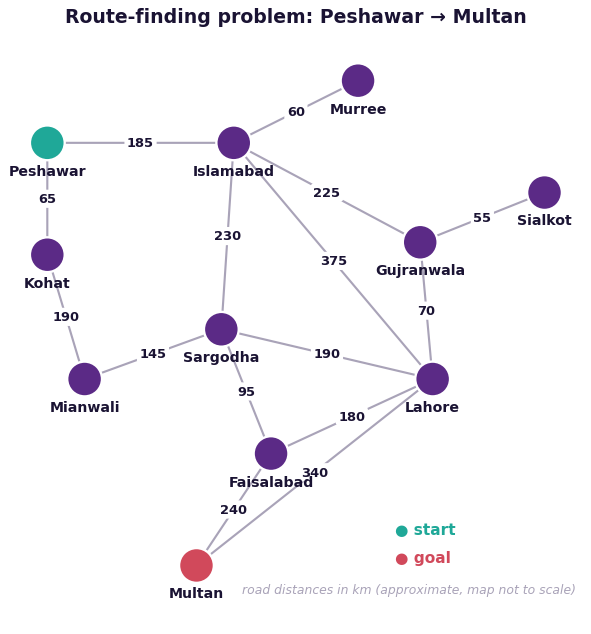

In [ ]:
#@title 📊 Visual explanation: our road map
def fig_city_map(path=None, title="Route-finding problem: Peshawar → Multan"):
    roads, _ = _map()
    pos = _layout()
    fig, ax = plt.subplots(figsize=(10, 7.6))
    cols = {"Peshawar": TEAL, "Multan": ROSE}
    draw_graph(ax, pos, [(a, b) for a, b, _ in roads], weights=[d for _, _, d in roads], colors=cols,
               path=path, r=0.28, fs=12, label_below=True, edge_fs=11)
    ax.text(5.6, -0.3, "● start", color=TEAL, fontsize=13, fontweight="bold")
    ax.text(5.6, -0.75, "● goal", color=ROSE, fontsize=13, fontweight="bold")
    ax.text(8.5, -1.25, "road distances in km (approximate, map not to scale)", ha="right", fontsize=10.5, color=GREY, style="italic")
    finish(fig, title)
    return fig

fig_city_map()
plt.show()

In Python we store the map as a **dictionary**: each city → its neighbours and distances.

In [ ]:
# ===== The problem: roads between cities (a GRAPH) =====
# Each city lists its neighbours and the road distance in km (approximate).
roads = {
    "Peshawar":   {"Islamabad": 185, "Kohat": 65},
    "Kohat":      {"Peshawar": 65, "Mianwali": 190},
    "Islamabad":  {"Peshawar": 185, "Murree": 60, "Sargodha": 230, "Gujranwala": 225, "Lahore": 375},
    "Murree":     {"Islamabad": 60},
    "Mianwali":   {"Kohat": 190, "Sargodha": 145},
    "Sargodha":   {"Islamabad": 230, "Mianwali": 145, "Faisalabad": 95, "Lahore": 190},
    "Gujranwala": {"Islamabad": 225, "Lahore": 70, "Sialkot": 55},
    "Sialkot":    {"Gujranwala": 55},
    "Lahore":     {"Islamabad": 375, "Gujranwala": 70, "Sargodha": 190, "Faisalabad": 180, "Multan": 340},
    "Faisalabad": {"Sargodha": 95, "Lahore": 180, "Multan": 240},
    "Multan":     {"Faisalabad": 240, "Lahore": 340},
}
print("Number of cities (states):", len(roads))
print("Neighbours of Islamabad:", list(roads["Islamabad"]))

---
## Part 2: The 5 parts of a problem
| Part | Meaning | In our map |
|---|---|---|
| **Initial state** | where we start | Peshawar |
| **Actions** | what we can do | take a road to a neighbour |
| **Result** | where an action takes us | the neighbour city |
| **Goal test** | are we done? | city == Multan |
| **Path cost** | how expensive | total km |

In [ ]:
# ===== The 5 parts of a search problem =====
initial_state = "Peshawar"

def actions(state):
    """Actions = the roads you can take from this city."""
    return [f"go to {city}" for city in roads[state]]

def result(state, action):
    """Transition model: what state do we reach after an action?"""
    return action.replace("go to ", "")

def goal_test(state):
    return state == "Multan"

def step_cost(state, action):
    return roads[state][result(state, action)]

print("Initial state :", initial_state)
print("Actions       :", actions(initial_state))
print("Result of 'go to Kohat' :", result(initial_state, "go to Kohat"))
print("Is Peshawar the goal?   :", goal_test("Peshawar"))
print("Cost of Peshawar → Kohat:", step_cost("Peshawar", "go to Kohat"), "km")

### Path cost
Different paths reach the goal with **different costs**. A good search should find the **cheapest** one.

In [ ]:
# ===== Path cost: add up the step costs along a path =====
def path_cost(path):
    return sum(roads[a][b] for a, b in zip(path, path[1:]))

candidate_paths = [
    ["Peshawar", "Islamabad", "Lahore", "Multan"],
    ["Peshawar", "Islamabad", "Sargodha", "Faisalabad", "Multan"],
    ["Peshawar", "Kohat", "Mianwali", "Sargodha", "Faisalabad", "Multan"],
]
for p in candidate_paths:
    print(" → ".join(p), "=", path_cost(p), "km")

---
## Part 3: The search tree
Search starts at the initial state and **expands** it (creates its children), then expands those children, and so on.

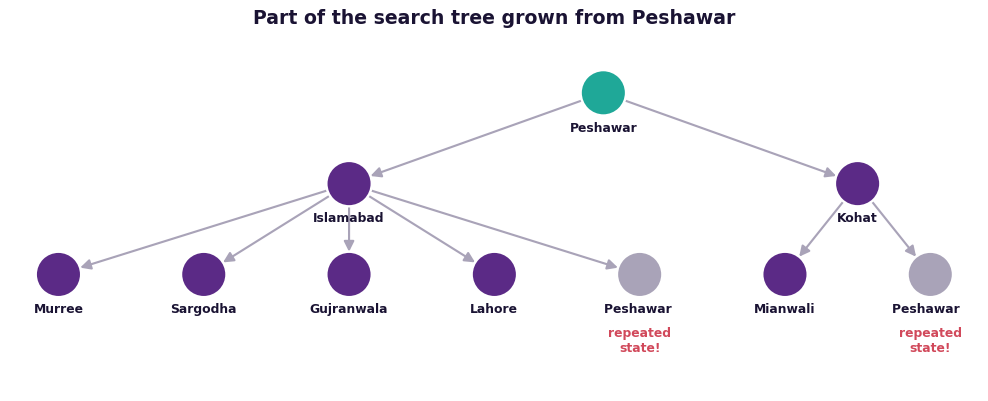

In [ ]:
#@title 📊 Visual explanation: the tree grown from Peshawar
def fig_search_tree_map():
    children = {"Peshawar": ["Islamabad", "Kohat"], "Islamabad": ["Murree", "Sargodha", "Gujranwala", "Lahore", "Peshawar "],
                "Kohat": ["Mianwali", "Peshawar  "]}
    pos = tree_layout(children, "Peshawar", gap=1.6)
    edges = [(p, c) for p, ks in children.items() for c in ks]
    cols = {"Peshawar ": GREY, "Peshawar  ": GREY, "Peshawar": TEAL}
    fig, ax = plt.subplots(figsize=(13, 4.8))
    draw_graph(ax, pos, edges, directed=True, colors=cols, r=0.25, fs=10.5, label_below=True)
    ax.text(pos["Peshawar "][0], -2.85, "repeated\nstate!", ha="center", fontsize=10.5, color=ROSE, fontweight="bold")
    ax.text(pos["Peshawar  "][0], -2.85, "repeated\nstate!", ha="center", fontsize=10.5, color=ROSE, fontweight="bold")
    ax.set_ylim(-3.3, 0.5)
    finish(fig, "Part of the search tree grown from Peshawar")
    return fig

fig_search_tree_map()
plt.show()

Notice the **grey** nodes: Peshawar appears again! Going back where you came from wastes time. Search algorithms keep an **explored list** to avoid this.

In [ ]:
# ===== Growing a search tree: expand nodes level by level =====
def expand(node_path):
    """Return child paths: one for each neighbour of the last city."""
    city = node_path[-1]
    return [node_path + [nb] for nb in roads[city]]

level = [["Peshawar"]]
for depth in range(3):
    print(f"Depth {depth}: {len(level)} node(s)")
    for p in level[:6]:
        print("    ", " → ".join(p))
    if len(level) > 6:
        print("     ...")
    level = [child for p in level for child in expand(p)]
print("\nNotice: the tree grows fast, and cities repeat (Peshawar → Islamabad → Peshawar).")

---
## Part 4: The Water Jug problem
You have a **4-litre** jug and a **3-litre** jug, with no markings. How can you get **exactly 2 litres** in the 4-litre jug?

- **State** = `(x, y)` = litres in the 4L jug, litres in the 3L jug
- **Start** = `(0, 0)` **Goal** = `(2, anything)`
- **Actions** = fill a jug, empty a jug, pour one jug into the other

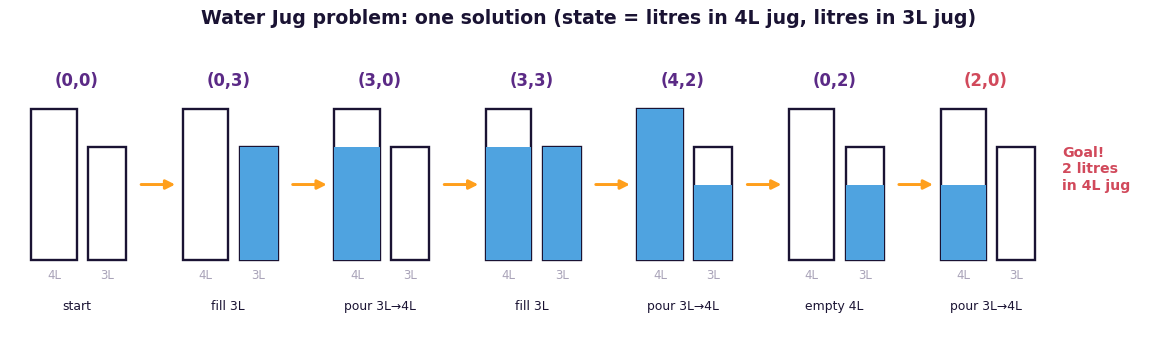

In [ ]:
#@title 📊 Visual explanation: one solution, step by step
def fig_water_jug():
    path = [(0, 0), (0, 3), (3, 0), (3, 3), (4, 2), (0, 2), (2, 0)]
    acts = ["start", "fill 3L", "pour 3L→4L", "fill 3L", "pour 3L→4L", "empty 4L", "pour 3L→4L"]
    fig, ax = plt.subplots(figsize=(14, 4.2))
    for i, ((x, y), a) in enumerate(zip(path, acts)):
        x0 = i * 2.0
        for j, (cap, amt, w) in enumerate([(4, x, 0.6), (3, y, 0.5)]):
            jx = x0 + j * 0.75
            ax.add_patch(Rectangle((jx, 0), w, cap * 0.5, fc=WHITE, ec=DARK, lw=2))
            if amt:
                ax.add_patch(Rectangle((jx, 0), w, amt * 0.5, fc="#4FA3E0", ec="none"))
            ax.text(jx + w / 2, -0.25, f"{cap}L", ha="center", fontsize=10, color=GREY)
        ax.text(x0 + 0.6, 2.3, f"({x},{y})", ha="center", fontsize=14, fontweight="bold",
                color=ROSE if x == 2 else PURPLE)
        ax.text(x0 + 0.6, -0.65, a, ha="center", fontsize=10.5, color=DARK)
        if i < len(path) - 1:
            arrow(ax, x0 + 1.45, 1.0, x0 + 1.9, 1.0, color=ORANGE, lw=2.5)
    ax.text(13.6, 1.2, "Goal!\n2 litres\nin 4L jug", fontsize=12, color=ROSE, fontweight="bold", va="center")
    ax.set_xlim(-0.3, 15.0); ax.set_ylim(-0.9, 2.6); ax.set_aspect("equal"); ax.axis("off")
    finish(fig, "Water Jug problem: one solution (state = litres in 4L jug, litres in 3L jug)")
    return fig

fig_water_jug()
plt.show()

In [ ]:
# ===== Water Jug problem =====
# State = (x, y): x litres in the 4L jug, y litres in the 3L jug
def jug_successors(state):
    x, y = state
    moves = {
        "Fill 3L":     (x, 3),
        "Fill 4L":     (4, y),
        "Empty 4L":    (0, y),
        "Empty 3L":    (x, 0),
        "Pour 3L→4L":  (min(4, x + y), max(0, y - (4 - x))),
        "Pour 4L→3L":  (max(0, x - (3 - y)), min(3, x + y)),
    }
    # keep only moves that actually change the state
    return {name: s for name, s in moves.items() if s != state}

print("From (0, 0):", jug_successors((0, 0)))
print("From (4, 0):", jug_successors((4, 0)))
print("From (3, 3):", jug_successors((3, 3)))

### How many states are there?
Let the computer explore **every** state it can reach from `(0, 0)`.

In [ ]:
# ===== Explore the whole state space =====
from collections import deque
seen, queue = {(0, 0)}, deque([(0, 0)])
while queue:
    s = queue.popleft()
    for nxt in jug_successors(s).values():
        if nxt not in seen:
            seen.add(nxt); queue.append(nxt)
print("Reachable states:", len(seen))
print(sorted(seen))

### Let the computer find the solution
This uses **Breadth-First Search**, which you will study properly in Lecture 6. Compare its answer with the picture above.

In [ ]:
# ===== Find a solution (a preview of Breadth-First Search from Lecture 6) =====
def solve_jug(start=(0, 0), goal_amount=2):
    queue = deque([(start, [])])      # (state, list of actions so far)
    seen = {start}
    while queue:
        state, plan = queue.popleft()
        if state[0] == goal_amount:
            return plan, state
        for action, nxt in jug_successors(state).items():
            if nxt not in seen:
                seen.add(nxt)
                queue.append((nxt, plan + [(action, nxt)]))

plan, final = solve_jug()
print("Start: (0, 0)")
for i, (action, s) in enumerate(plan, 1):
    print(f"Step {i}: {action:12s} → {s}")
print("Solved in", len(plan), "steps. Final state:", final)

---
## Part 5: The 8-Puzzle
Slide the tiles to reach the goal. We think of it as **moving the blank** up, down, left or right.

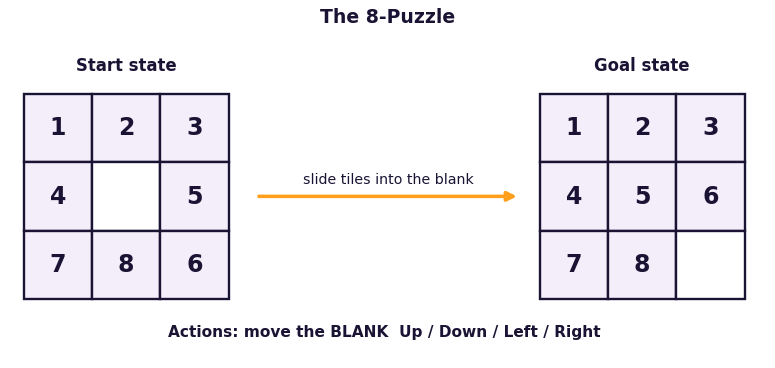

In [ ]:
#@title 📊 Visual explanation: start and goal
def fig_8puzzle():
    fig, ax = plt.subplots(figsize=(12, 4.4))
    board(ax, 0.2, 2.0, "123405786", title="Start state")
    board(ax, 7.0, 2.0, "123456780", title="Goal state")
    arrow(ax, 3.3, 1.55, 6.7, 1.55, color=ORANGE, lw=3, text="slide tiles into the blank", fs=12)
    ax.text(4.95, -0.3, "Actions: move the BLANK  Up / Down / Left / Right", ha="center", fontsize=13, color=DARK, fontweight="bold")
    ax.set_xlim(0, 10); ax.set_ylim(-0.6, 3.5); ax.set_aspect("equal"); ax.axis("off")
    finish(fig, "The 8-Puzzle")
    return fig

fig_8puzzle()
plt.show()

In [ ]:
# ===== 8-Puzzle: state representation =====
# A state is a string of 9 characters read row by row; '0' is the blank.
start = "123405786"
goal  = "123456780"

def show(state):
    for r in range(3):
        print(" ".join(state[3*r:3*r+3]).replace("0", "_"))
    print()

print("Start:"); show(start)
print("Goal:");  show(goal)

### Actions: move the blank
From any state there are **2 to 4** possible moves, depending on where the blank is.

In [ ]:
# ===== 8-Puzzle: actions = move the blank =====
def puzzle_successors(state):
    i = state.index("0")
    r, c = divmod(i, 3)
    result = {}
    for name, dr, dc in [("Up", -1, 0), ("Down", 1, 0), ("Left", 0, -1), ("Right", 0, 1)]:
        nr, nc = r + dr, c + dc
        if 0 <= nr < 3 and 0 <= nc < 3:
            j = nr * 3 + nc
            s = list(state); s[i], s[j] = s[j], s[i]
            result[name] = "".join(s)
    return result

for move, s in puzzle_successors(start).items():
    print("Blank moves", move); show(s)

In [ ]:
# ===== Solve the start state with the same BFS idea =====
def solve_puzzle(start, goal):
    queue, seen = deque([(start, [])]), {start}
    while queue:
        state, moves = queue.popleft()
        if state == goal:
            return moves, len(seen)
        for m, nxt in puzzle_successors(state).items():
            if nxt not in seen:
                seen.add(nxt); queue.append((nxt, moves + [m]))

moves, generated = solve_puzzle(start, goal)
print("Moves of the blank:", moves)
print("States generated  :", generated)
import math
print("\nTotal possible 8-puzzle arrangements = 9! =", math.factorial(9), "(half of them reachable)")

---
## 📝 Lab Tasks
1. Add **two new cities** to the map (e.g. Bahawalpur, D.I. Khan) with roads. Print their neighbours.
2. Change the goal to **Sialkot** and write two different paths from Peshawar. Which is cheaper?
3. Water jug: can you get **1 litre**? Change `goal_amount` and run `solve_jug` again.
4. 8-puzzle: try the start state `"413056782"`. How many moves does the solution need?
5. **Think:** write the 5 parts of the problem for *"a robot delivering food inside a hospital"*.